Non-Negative Basis Pursuit DeNoising (ADMM)
===========================================

This example demonstrates the solution of a non-negative sparse coding
problem

  $$\mathrm{argmin}_{\mathbf{x}} \; (1/2) \| \mathbf{y} - D \mathbf{x} \|_2^2
  + \lambda \| \mathbf{x} \|_1 + \iota_{\mathrm{NN}}(\mathbf{x}) \;,$$

where $D$ the dictionary, $\mathbf{y}$ the signal to be represented,
$\mathbf{x}$ is the sparse representation, and $\iota_{\mathrm{NN}}$ is
the indicator function of the non-negativity constraint.

In this example the problem is solved via ADMM, while Accelerated PGM is
used in a [companion example](sparsecode_nn_apgm.rst).

In [1]:
import numpy as np

import komplot as kplt

import scico.numpy as snp
from scico import functional, linop, loss
from scico.optimize.admm import ADMM, MatrixSubproblemSolver
from scico.util import device_info
kplt.config_notebook_plotting()

Create random dictionary, reference random sparse representation, and
test signal consisting of the synthesis of the reference sparse
representation.

In [2]:
m = 32  # signal size
n = 128  # dictionary size
s = 10  # sparsity level

np.random.seed(1)
D = np.random.randn(m, n).astype(np.float32)
D = D / np.linalg.norm(D, axis=0, keepdims=True)  # normalize dictionary

xt = np.zeros(n, dtype=np.float32)  # true signal
idx = np.random.randint(low=0, high=n, size=s)  # support of xt
xt[idx] = np.random.rand(s)
y = D @ xt + 5e-2 * np.random.randn(m)  # synthetic signal

xt = snp.array(xt)  # convert to jax array
y = snp.array(y)  # convert to jax array

Set up the forward operator and ADMM solver object.

In [3]:
lmbda = 1e-1
A = linop.MatrixOperator(D)
f = loss.SquaredL2Loss(y=y, A=A)
g_list = [lmbda * functional.L1Norm(), functional.NonNegativeIndicator()]
C_list = [linop.Identity((n)), linop.Identity((n))]
rho_list = [1.0, 1.0]
maxiter = 100  # number of ADMM iterations

solver = ADMM(
    f=f,
    g_list=g_list,
    C_list=C_list,
    rho_list=rho_list,
    x0=A.adj(y),
    maxiter=maxiter,
    subproblem_solver=MatrixSubproblemSolver(),
    itstat_options={"display": True, "period": 10},
)

Run the solver.

In [4]:
print(f"Solving on {device_info()}\n")
x = solver.solve()

Solving on GPU (NVIDIA GeForce RTX 2080 Ti)



Iter  Time      Objective  Prml Rsdl  Dual Rsdl
-----------------------------------------------
   0  1.14e+00  2.810e+00  1.435e+00  6.655e+00


  10  3.81e+00  4.879e-01  3.589e-02  8.689e-02


  20  4.55e+00  4.753e-01  1.018e-02  2.879e-02


  30  5.28e+00  4.737e-01  2.998e-03  1.086e-02


...

  60  7.54e+00  4.730e-01  1.275e-04  2.184e-04


  70  8.32e+00  4.730e-01  2.421e-05  5.758e-05


  80  9.07e+00  4.730e-01  7.408e-06  2.496e-05


  90  9.92e+00  4.730e-01  3.409e-06  1.241e-05


  99  1.07e+01  4.730e-01  1.896e-06  6.844e-06


Plot the recovered coefficients and signal.

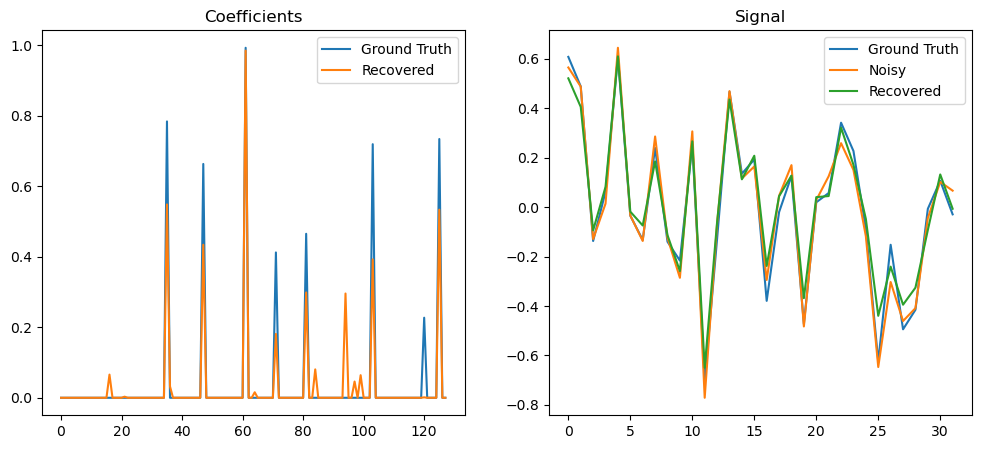

In [5]:
fig, ax = kplt.subplots(nrows=1, ncols=2, figsize=(12, 5))
kplt.plot(
    np.vstack((xt, solver.x)).T,
    title="Coefficients",
    legend=("Ground Truth", "Recovered"),
    ax=ax[0],
)
kplt.plot(
    np.vstack((D @ xt, y, D @ solver.x)).T,
    title="Signal",
    legend=("Ground Truth", "Noisy", "Recovered"),
    ax=ax[1],
)
fig.show()